# Medium - Isolate the wheat, find the signal

In the **Easy** notebook we averaged NDVI over a whole 5 × 5 km bbox. That mixed wheat fields with roads, houses, fallow ground - the signal was diluted. Today we fix that.

## What we add to Easy

1. **USDA Cropland Data Layer (CDL)** - a free, authoritative pixel-by-pixel crop classification of the entire US. We use it to mask out everything that's not winter wheat.
2. **USDA NASS QuickStats API** - historical yields per county + the weekly Crop Progress report. Our ground truth.
3. **Erosion** - a 1-line trick to drop field-edge mixed pixels and recover the textbook NDVI peak.
4. **Phenology overlay** - we mark the heading and harvest dates on the NDVI curve, derived from NASS itself.

All free. All public. Same data the pros use.

Run time: \~5 minutes (includes one-time download of \~3 GB CDL national raster, cached locally). On Colab the disk is ephemeral - re-runs in a new session redownload. Mount Drive for persistence.

## 0. Setup

Extra libraries vs Easy: `requests` (USDA download), `python-dotenv` (read your NASS key from `.env`), `rioxarray` (handle the CDL GeoTIFF), `scipy` (the erosion).

You need a **free NASS QuickStats API key** to query yields. Get one in 30 seconds at https://quickstats.nass.usda.gov/api - they email it instantly. Then either put it in a `.env` file as `NASS_API_KEY=...` or set the environment variable manually.

In [1]:
# %pip install -q pystac-client planetary-computer odc-stac rioxarray requests python-dotenv scipy matplotlib pandas numpy

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pystac_client import Client
import planetary_computer
import odc.stac
import rioxarray
from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
from scipy.ndimage import binary_erosion

load_dotenv()
NASS_API_KEY = os.environ.get("NASS_API_KEY")
if not NASS_API_KEY:
    NASS_API_KEY = input("Paste your NASS QuickStats API key: ").strip()

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print("Setup ready.")

Setup ready.


## 1. Pick the area and the season

Same bbox as the Easy notebook (Sumner County, KS). We target **2025** - the most recent full season USDA has published a CDL for, so our wheat mask is up-to-date.

In [2]:
BBOX = [-97.50, 37.20, -97.45, 37.25]
STATE = "KS"
COUNTY = "SUMNER"
YEAR = 2025

print(f"Area : ~{(BBOX[2]-BBOX[0])*88:.1f} km x {(BBOX[3]-BBOX[1])*111:.1f} km")
print(f"Year : {YEAR}")

Area : ~4.4 km x 5.5 km
Year : 2025


## 2. Find the wheat with the USDA CDL

The Cropland Data Layer assigns a crop class to every 30 m pixel of the lower-48. Code `24` = Winter Wheat.

### Why we go straight to the USDA portal

Microsoft Planetary Computer mirrors the CDL but **stops at 2021**. We want the latest year (2025), so we fetch directly from USDA: `https://www.nass.usda.gov/Research_and_Science/Cropland/Release/datasets/{year}_30m_cdls.zip`.

First call: \~3 GB download (one-time per year, cached). Subsequent calls: instant.

The national TIFF is huge (\~10 GB unzipped, 9 billion pixels). We never load it fully - `rioxarray` reads only the window matching our bbox (\~MB).

In [3]:
WINTER_WHEAT_CLASS = 24
CDL_CACHE = Path("data/bronze/usda_cdl")
CDL_CACHE.mkdir(parents=True, exist_ok=True)


def fetch_usda_cdl(year: int) -> Path:
    """Download the national CDL GeoTIFF for a given year. Cached locally."""
    cached = next(CDL_CACHE.rglob(f"{year}_30m_cdls.tif"), None)
    if cached is not None:
        print(f"Cache hit: {cached}")
        return cached

    url = f"https://www.nass.usda.gov/Research_and_Science/Cropland/Release/datasets/{year}_30m_cdls.zip"
    zip_path = CDL_CACHE / f"{year}_30m_cdls.zip"
    print(f"Downloading {url}\n  (~3 GB, one-time)...")
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        done = 0
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=16 * 1024 * 1024):
                f.write(chunk)
                done += len(chunk)
                if total:
                    print(f"\r  {100*done/total:5.1f}%", end="", flush=True)
        print()
    print("Unzipping...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(CDL_CACHE)
    zip_path.unlink()
    return next(CDL_CACHE.rglob(f"{year}_30m_cdls.tif"))


def load_cdl_for_bbox(bbox_lonlat, year):
    """Open the cached national CDL and clip to the bbox. Returns a
    georeferenced xarray DataArray (CRS preserved via rioxarray)."""
    tif = fetch_usda_cdl(year)
    cdl = rioxarray.open_rasterio(tif).squeeze()
    bbox_proj = transform_bounds("EPSG:4326", cdl.rio.crs, *bbox_lonlat)
    return cdl.rio.clip_box(*bbox_proj)


cdl_da = load_cdl_for_bbox(BBOX, YEAR)
wheat_mask = (cdl_da.values == WINTER_WHEAT_CLASS)
print(f"\nWheat pixels in bbox: {wheat_mask.sum()} / {wheat_mask.size} "
      f"({100*wheat_mask.mean():.1f}%)")

  (~3 GB, one-time)...
  100.0%
Unzipping...

Wheat pixels in bbox: 11524 / 28500 (40.4%)


### 2.1 Look at it

Left: the full CDL with every crop class. Right: only the winter wheat pixels. This is where we'll measure NDVI - and *only* there.

Note: this view is in the CDL's native **Albers** projection. The aspect may look slightly different from the Sentinel-2 maps later - Section 4 will reproject everything onto the same grid.

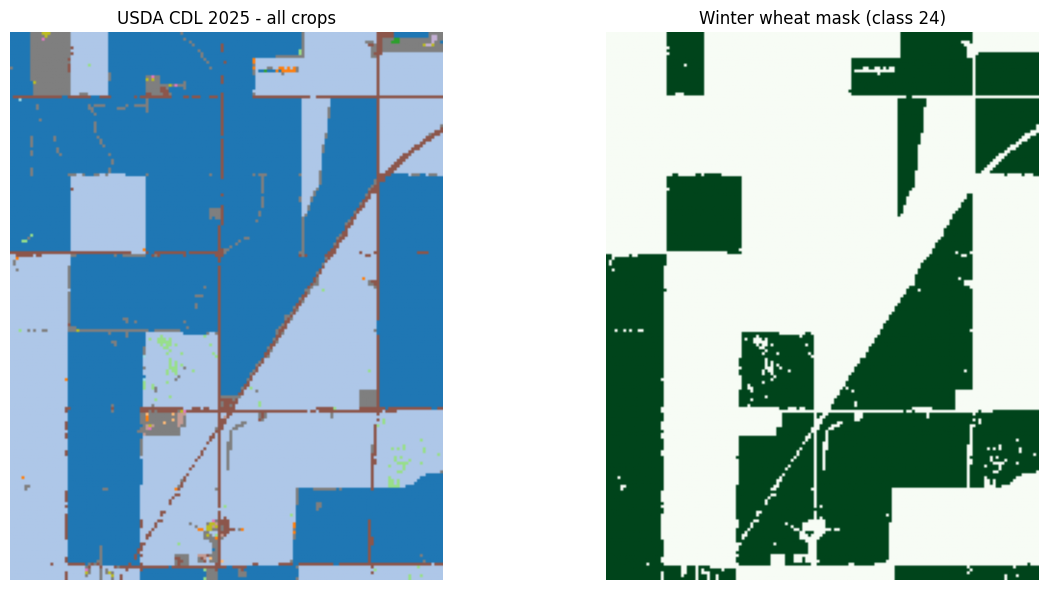

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(cdl_da.values, cmap="tab20")
axes[0].set_title(f"USDA CDL {YEAR} - all crops")
axes[0].axis("off")
axes[1].imshow(wheat_mask, cmap="Greens")
axes[1].set_title("Winter wheat mask (class 24)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Pull every Sentinel-2 image of the season

Same STAC search as in Easy: every L2A scene over the bbox in 2025 with less than 30% cloud cover. Then we load three bands lazily.

In [5]:
items = list(catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime=f"{YEAR}-01-01/{YEAR}-12-31",
    query={"eo:cloud_cover": {"lt": 30}},
).items())
print(f"Found {len(items)} scenes")

s2 = odc.stac.load(
    items,
    bands=["B04", "B08", "SCL"],
    bbox=BBOX,
    resolution=10,
    groupby="solar_day",
    chunks={},
)

Found 40 scenes


## 4. NDVI on wheat pixels only

Two things going on here:

1. **Cloud mask** via the SCL band (we drop cloud shadow, medium/high-prob cloud, cirrus, snow).
2. **Reproject the CDL mask** from 30 m Albers onto the 10 m UTM Sentinel-2 grid. We use nearest-neighbour because class codes are categorical - interpolation would invent classes that don't exist.

We then average NDVI over **only the wheat pixels** for each acquisition date. One number per date.

In [6]:
BAD_SCL = [3, 8, 9, 10, 11]
valid = ~s2["SCL"].isin(BAD_SCL)

red = s2["B04"].where(valid).astype("float32")
nir = s2["B08"].where(valid).astype("float32")
ndvi = (nir - red) / (nir + red + 1e-6)

# Reproject the wheat mask onto the S2 grid. We write CRS explicitly on both
# sides so rioxarray has all the metadata it needs.
s2_epsg = int(s2["spatial_ref"].values)
s2_target = s2.isel(time=0).rio.write_crs(f"EPSG:{s2_epsg}")
wheat_da = (cdl_da == WINTER_WHEAT_CLASS).astype("uint8").rio.write_crs(cdl_da.rio.crs)
wheat_on_s2 = wheat_da.rio.reproject_match(
    s2_target, resampling=Resampling.nearest
) > 0

n_wheat = int(wheat_on_s2.sum())
print(f"Wheat pixels on the S2 grid: {n_wheat} "
      f"({100*n_wheat/wheat_on_s2.size:.1f}% of bbox)")

ndvi_ts = ndvi.where(wheat_on_s2).mean(dim=["y", "x"]).compute()
df_ndvi = pd.DataFrame({
    "date": pd.to_datetime(ndvi_ts["time"].values).date,
    "ndvi": ndvi_ts.values,
}).dropna().sort_values("date").reset_index(drop=True)

print(f"NDVI range over the season: {df_ndvi['ndvi'].min():.2f} -> {df_ndvi['ndvi'].max():.2f}")
df_ndvi.head()

Wheat pixels on the S2 grid: 102081 (40.0% of bbox)


/Users/lucasinglese/Library/Caches/pypoetry/virtualenvs/quantlake-UZuDkhhv-py3.13/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


NDVI range over the season: 0.13 -> 0.49


,date,ndvi
0,2025-01-03,0.292679
1,2025-01-08,0.128416
2,2025-01-28,0.281974
3,2025-02-22,0.185388
4,2025-02-27,0.285539


## 4.1 Sanity check - does the mask really sit on the wheat?

Before trusting the time series, we look at a single date around the expected peak (mid-May) and check 3 things side by side:

1. The wheat mask itself.
2. NDVI over the **full** bbox (no mask).
3. NDVI restricted to wheat pixels.

If the mask is well-placed and the year was decent, panel 3 should be visibly greener than panel 2.

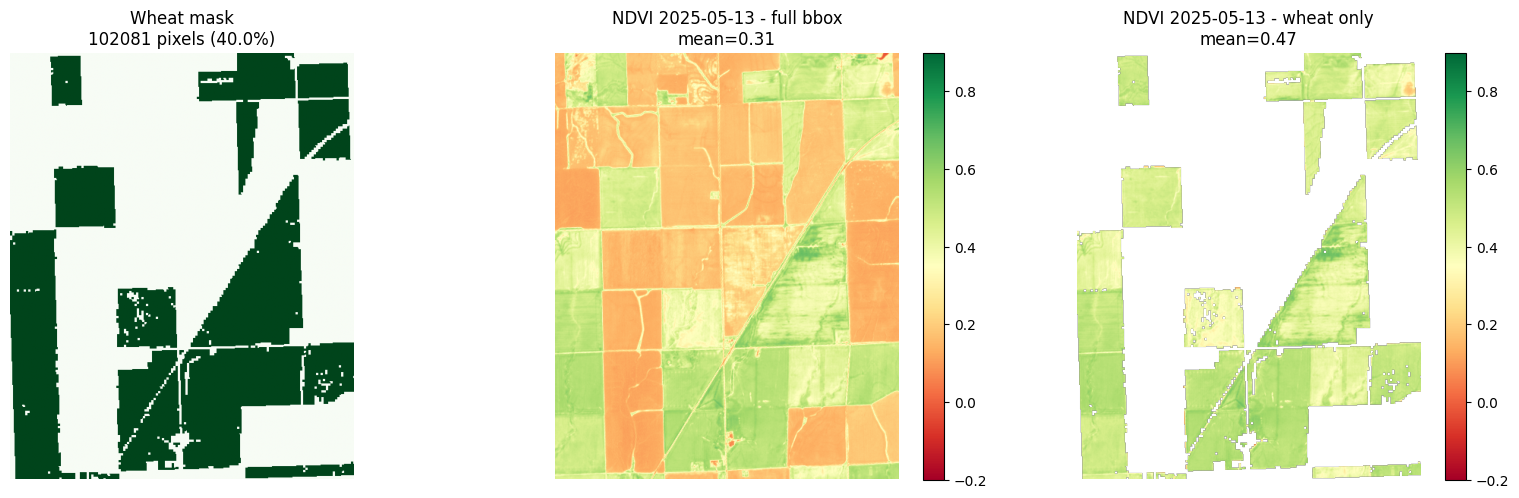

In [7]:
times = pd.to_datetime(ndvi["time"].values)
i_peak = int(np.argmin(np.abs(times - pd.Timestamp(f"{YEAR}-05-15"))))
actual_date = pd.Timestamp(times[i_peak]).date()
ndvi_peak = ndvi.isel(time=i_peak).compute()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(wheat_on_s2.values, cmap="Greens")
axes[0].set_title(f"Wheat mask\n{int(wheat_on_s2.sum())} pixels ({100*float(wheat_on_s2.mean()):.1f}%)")
axes[0].axis("off")

im1 = axes[1].imshow(ndvi_peak.values, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
axes[1].set_title(f"NDVI {actual_date} - full bbox\nmean={float(ndvi_peak.mean()):.2f}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

ndvi_peak_masked = ndvi_peak.where(wheat_on_s2)
im2 = axes[2].imshow(ndvi_peak_masked.values, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
axes[2].set_title(f"NDVI {actual_date} - wheat only\nmean={float(ndvi_peak_masked.mean()):.2f}")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 4.2 Clean the signal - drop the field edges

If our mean NDVI looks lower than the textbook peak (0.7–0.8 at heading), the culprit is often **mixed pixels** at field edges - partial wheat / partial road / partial fence row. They sit just inside the mask but carry weak NDVI, dragging the average down.

The fix: **binary erosion** of the mask. We shrink it by 3 pixels (= 30 m) on every side, keeping only the core of each field. Quick, free, and the peak NDVI usually jumps by 0.05–0.10.

In [8]:
mask_arr = wheat_on_s2.values
mask_eroded_arr = binary_erosion(mask_arr, iterations=3)
mask_eroded = wheat_on_s2.copy(data=mask_eroded_arr)

print(f"Wheat pixels before erosion : {int(mask_arr.sum()):>7d}")
print(f"Wheat pixels after erosion  : {int(mask_eroded.sum()):>7d} "
      f"({100*int(mask_eroded.sum())/mask_arr.sum():.0f}% kept)")

ndvi_ts_eroded = ndvi.where(mask_eroded).mean(dim=["y", "x"]).compute()
df_eroded = pd.DataFrame({
    "date": pd.to_datetime(ndvi_ts_eroded["time"].values).date,
    "ndvi": ndvi_ts_eroded.values,
}).dropna().sort_values("date").reset_index(drop=True)

print(f"\nPeak NDVI: original = {df_ndvi['ndvi'].max():.3f}, "
      f"eroded = {df_eroded['ndvi'].max():.3f}")

Wheat pixels before erosion :  102081
Wheat pixels after erosion  :   81306 (80% kept)

Peak NDVI: original = 0.490, eroded = 0.491


## 5. Ground truth - USDA NASS QuickStats

[NASS QuickStats](https://quickstats.nass.usda.gov/) is the official USDA database. The API is free with a key.

For this notebook we pull one thing: the **Crop Progress** report for our state and season (NASS only publishes progress per state, not per county). It tells us, week by week, what % of the wheat is planted, headed, harvested, etc. We use it to mark the **heading** and **harvest** dates on our NDVI curve - so we can read the satellite signal against the official phenological calendar.

*(We could also pull historical yields here for context; that's exactly what the **Hard** notebook does, when we actually compare NDVI to yield.)*

In [9]:
NASS_URL = "https://quickstats.nass.usda.gov/api/api_GET/"


def nass_query(params: dict) -> pd.DataFrame:
    """Query NASS QuickStats and return a DataFrame."""
    p = {"key": NASS_API_KEY, "format": "JSON", **params}
    r = requests.get(NASS_URL, params=p, timeout=60)
    r.raise_for_status()
    return pd.DataFrame(r.json()["data"])

In [10]:
# 5.2 - Crop Progress for our season (state level)
progress = nass_query({
    "source_desc": "SURVEY",
    "commodity_desc": "WHEAT",
    "statisticcat_desc": "PROGRESS",
    "agg_level_desc": "STATE",
    "state_alpha": STATE,
    "year": str(YEAR),
})
progress = progress[progress["short_desc"].str.contains("WINTER", na=False)].copy()
progress["week_ending"] = pd.to_datetime(progress["week_ending"])
progress["pct"] = pd.to_numeric(progress["Value"], errors="coerce")


def stage_50pct(df, keyword):
    sub = df[df["short_desc"].str.contains(keyword, case=False, na=False)]
    sub = sub[sub["pct"] >= 50]
    return sub["week_ending"].min() if not sub.empty else None


stages = {
    "Headed (50%)":    stage_50pct(progress, "HEADED"),
    "Harvested (50%)": stage_50pct(progress, "HARVESTED"),
}
stages

{'Headed (50%)': Timestamp('2025-05-11 00:00:00'),
 'Harvested (50%)': Timestamp('2025-06-29 00:00:00')}

## 6. Putting it all together

Final chart: NDVI of wheat pixels through the season - both the **raw mask** (grey, with edge dilution) and the **eroded core** (green, cleaner). Vertical dashed lines mark the NASS phenological stages so you can read the satellite signal against the official calendar.

This is the kind of view you'd refresh weekly during the growing season and feed into a yield model.

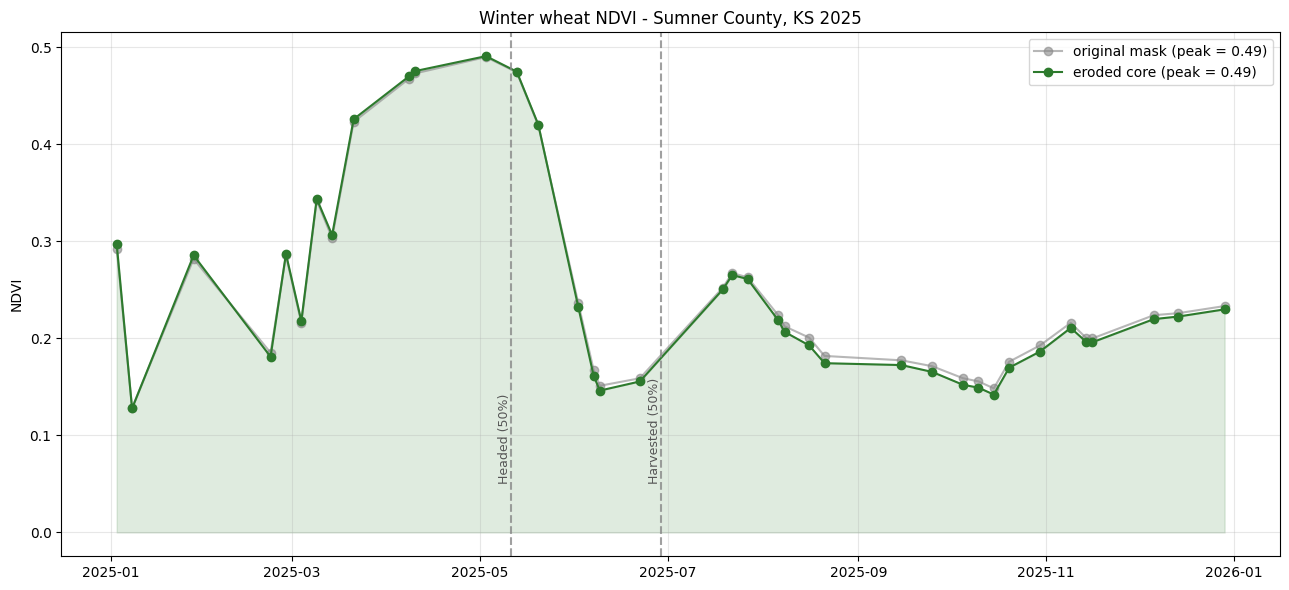

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_ndvi["date"], df_ndvi["ndvi"], "o-", color="#888", alpha=0.6,
        label=f"original mask (peak = {df_ndvi['ndvi'].max():.2f})")
ax.plot(df_eroded["date"], df_eroded["ndvi"], "o-", color="#2d7a2d",
        label=f"eroded core (peak = {df_eroded['ndvi'].max():.2f})")
ax.fill_between(df_eroded["date"], df_eroded["ndvi"], alpha=0.15, color="#2d7a2d")

for label, date in stages.items():
    if date is not None:
        ax.axvline(date, ls="--", color="#888", alpha=0.8)
        ax.text(date, 0.05, label, rotation=90, va="bottom", ha="right",
                fontsize=9, color="#555")

ax.set_ylabel("NDVI")
ax.set_title(f"Winter wheat NDVI - {COUNTY.title()} County, {STATE} {YEAR}")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. What you just did

You now have a pipeline that, for any US county and any year since 2008, produces:

- A clean winter-wheat-only NDVI seasonal curve.
- The official phenological calendar from USDA.
- The historical yield context.

All with three free public sources. **This is the medium-complexity version of a real ag-finance signal pipeline.**

## Next: the **Hard** notebook

A single season isn't enough - what you really want is **multiple years overlaid** so you can spot anomalies. Is this NDVI curve above or below normal for this stage? That's where the trading signal lives.

Head to `03_hard.ipynb` to do exactly that.